# **CO-OPS Extreme Water Levels: GEV Analysis**

Last updated on: 10/17/2025

## Overview
NOAA's Center for Operational Oceanographic Products and Services (CO-OPS) is the nation's source for [coastal inundation data](https://tidesandcurrents.noaa.gov) through its network of long-term water level gauges. In this notebook, we will walk through the steps for completing a GEV extreme value analysis.

This notebook is designed to explore a single station. Users can choose their station of interest here: [Extreme Water Levels Map](https://tidesandcurrents.noaa.gov/est/). For this example we will use [Sewells Point, VA (8638610)](https://tidesandcurrents.noaa.gov/est/est_station.shtml?stnid=8638610).

## Prerequisites and running the Notebook
This notebook uses Python programming and users may run it either in **Google Colab** or **Jupyter Notebook**.

* **Jupyter Notebook:** Recommended if you prefer to work offline and manage libraries and dependencies personally.
* **Google Colab:** The best option for cloud-based instant access, seamless cooperation, and if you have a good internet connection.

This notebook is designed so that people with limited familiarity with Python can run it.

### Using Google Colab

There are two ways to open this notebook in Colab.

**Method 1: Open directly from GitHub (Recommended)**

1.  Open [Google Colab](https://colab.research.google.com/).
2.  In the menu bar, go to **File > Open Notebook**.
3.  In the popup window, click on the **GitHub** tab.
4.  Paste the repository URL into the search bar and press Enter:
    `https://github.com/NOAA-CO-OPS/Coastal_Hazards_Example_Notebooks`
5.  Click on `CO-OPS_GEV_Extreme_Value_Analysis_Notebook/CO-OPS_GEV_Extreme_Value_Analysis_Notebook.ipynb` to open it.

**Method 2: Download and Upload (All Files)**

This method downloads the entire Coastal_Hazards_Example_Notebooks repository.

1.  Go to the [main GitHub repository](https://github.com/NOAA-CO-OPS/Coastal_Hazards_Example_Notebooks).
2.  Click the green **Code** button, then select **Download ZIP**.
3.  Extract the ZIP file on your computer. This folder contains the notebook (`.ipynb`).
4.  Open [Google Colab](https://colab.research.google.com/).
5.  Go to **File > Upload notebook...** and select the `CO-OPS_GEV_Extreme_Value_Analysis_Notebook.ipynb` file from the folder you just extracted.

### Using Jupyter Notebook

This method downloads the entire Coastal_Hazards_Example_Notebooks repository.

1.  Go to the [main GitHub repository](https://github.com/NOAA-CO-OPS/Coastal_Hazards_Example_Notebooks).
2.  Click the green **Code** button, then select **Download ZIP**.
3.  Extract the ZIP file on your computer.
4.  Start Jupyter Notebook on your local machine and navigate to the extracted folder (`.../CO-OPS_GEV_Extreme_Value_Analysis_Notebook/`) to open `CO-OPS_GEV_Extreme_Value_Analysis_Notebook.ipynb`.

### ▶️ Running the Notebook

Once you have the notebook open:

1.  [Explore different station/s](https://tidesandcurrents.noaa.gov/est/) and decide which you want to analyze.
2.  In **Step 3** of the notebook, change the **station variable** and **unit of interest**.
3.  In the top menu, click **Runtime** and choose **Run All**.
4.  When the 'Choose Files' box in **Step 2** becomes active, click on it.
5.  You will see a green check mark to the left of each cell as it is successfully executed.

Users should be prepared to commit 30 minutes to familiarize themselves with the notebook, upload data, run code and examine results.

## Learning Outcomes
In this notebook users will be able to:
  1.  Prepare a monthly maxima or minima time series for a GEV analysis by first detrending the series.
  2.  Then the annual maxima or minma series are generated
  3.  Examine and plot the results as they should appear when a station is published to the website.

## Data Source and Documentations
Input and output documentation can be found in the [CO-OPS Data API](https://api.tidesandcurrents.noaa.gov/api/prod/), [CO-OPS Derived Product API v0.1](https://api.tidesandcurrents.noaa.gov/dpapi/prod/) and the [CO-OPS Metadata API](https://api.tidesandcurrents.noaa.gov/mdapi/prod/).

Standard templates are available within the [CO-OPS API URL Builder](https://tidesandcurrents.noaa.gov/api-helper/url-generator.html), but this notebook is designed to give you more flexiblity through building our own API template to generate queries from our Data API, MetaData API, and Derived Product API. All data used for this notebook come from the CO-OPS API


## Software
This tutorial uses the following Python packages:
- datetime
- requests
- time
- pandas
- numpy
- matplotlib
- math
- plotly
- warnings


This tutorial also uses rpy2.ipython and rpy2.robjects.packages to be able to load the R package "extRemes" and use it in a Colab or Jupyter notebook.

## **Step 1**
## Install and Load Packages
Lets check if you have these packages installed. If not, this cell will install them.

In [ ]:
# @title
import subprocess, sys
packages = ["datetime","requests","time","pandas","numpy","matplotlib","warnings","math","plotly"]
for package in packages:
    try:
        __import__(package)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])

In [ ]:
# @title Importing python packages
import datetime as dt
from datetime import timedelta
import requests
import time as time
import pandas as pd
import numpy as np
import warnings
import math
from math import exp
import plotly.graph_objects as go

#this is to suppress user warnings
warnings.filterwarnings("ignore")

In [ ]:
# @title Load the rpy2 extension for using R in Python. This will take about a minute and a half.
%load_ext rpy2.ipython

import rpy2.robjects.packages as rpackages
utils = rpackages.importr('utils')
utils.chooseCRANmirror(ind=1)

utils.install_packages('extRemes')

(as ‘lib’ is unspecified)








	‘/tmp/Rtmpi5c3mf/downloaded_packages’



<rpy2.rinterface_lib.sexp.NULLType object at 0x78dfd85d53d0> [0]

## **Step 2**
## Here we choose the station of interest
Click [here](https://tidesandcurrents.noaa.gov/est/) to see a map of stations to get Station IDs


### The stations with the longest periods of record (greater than 95 years) are:
|Station ID and Name  | Station ID and Name | Station ID and Name|
|:--------------------|:--------------------|:--------------------|
|1612340	Honolulu, HI	| 8574680	Baltimore, MD	| 8771450	Galveston, TX |
|1617760	Hilo, HI	| 8575512	Annapolis, MD	| 9410170	San Diego, CA |
|8410140	Eastport, ME	|	8594900	Washington, DC	| 9410230	La Jolla, CA|
|8418150	Portland, ME	|	8638610	Sewells Point, VA	| 9410660	Los Angeles, CA|
|8443970	Boston, MA	| 8665530	Charleston, SC	| 9414290 San Francisco, CA|
|8452660	Newport, RI	| 8720030	Fernandina Beach, FL | 9439040	Astoria, OR|
|8518750	The Battery, NY	|	8724580	Key West, FL| 9447130	Seattle, WA|
|8534720	Atlantic City, NJ	|	8727520	Cedar Key, FL | 9450460	Ketchikan, AK|
|8557380	Lewes, DE	| 8729840	Pensacola, FL| 9451600	Sitka, AK |

In [ ]:
#input station ID below
station = '8638610'

#options are metric or english
units = 'metric'

#options are 'high' for maxima or 'low' for minima
levelType = 'high'

## **Step 3**
## Next, we pull in our station's relative sea level trend, monthly extremes data, and data epoch info from CO-OPS APIs

In [ ]:
# @title Grabs default relative sea level trend
#getting sea level trend from dpapi
product = "sealvltrends"
affil = "us"
server = "https://api.tidesandcurrents.noaa.gov/dpapi/prod/webapi/product/"

myurl = (server + product + ".json?station=" + station + "&affil=" + affil + "&units="+units)

# Use "requests" to get the MSL Trend
urlResponse = requests.get(myurl)
content=urlResponse.json()

# Assign data to variables.
mydata = content['SeaLvlTrends']

# Make it a Dataframe
mytrend = pd.DataFrame(mydata)

stationName = mytrend['stationName'].iloc[0]

seasonal = mytrend['seasonalAverage'].iloc[0]

if units == 'metric':
  mytrendrate = mytrend['trend'].iloc[0]/1000

  trend_text = str(stationName) + '  ' + str(mytrendrate*1000) + ' +/- ' + str(round(1.96 * mytrend['trendError'].iloc[0],2)) + ' mm/yr'

  #check for earthquake stations
  try:
    mytrendrate0 = mytrend['trend0'].iloc[0]/1000
    endDate0 = mytrend['endDate0'].iloc[0]
    shift0 = mytrend['y2000_offset0'].iloc[0]
    shift = mytrend['y2000_offset'].iloc[0]
  except:
    mytrendrate0 = np.nan
else:
  mytrendrate = mytrend['trend'].iloc[0]/120

  trend_text = str(round(mytrendrate*120,2)) + '+/-' + str(round(mytrend['trendError'].iloc[0],2)) + ' inches/decade'

  try:
    mytrendrate0 = mytrend['trend0'].iloc[0]/120
    endDate0 = mytrend['endDate0'].iloc[0]
    shift0 = mytrend['y2000_offset0'].iloc[0]
    shift = mytrend['y2000_offset'].iloc[0]
  except:
    mytrendrate0 = np.nan

trend_text

'Sewells Point  4.83 +/- 0.22 mm/yr'

In [ ]:
# @title Datum info
#grab datum info
server = 'https://api.tidesandcurrents.noaa.gov/mdapi/prod/webapi/stations/'

myurl = (server + station + '/datums.json?units='+units)

urlResponse = requests.get(myurl)
content=urlResponse.json()

# Assign data to variables.
epoch_info = content['epoch']
datums_info = pd.DataFrame(content['datums'])

#if we can't find the epoch info, default to NTDE
if epoch_info == '0000-0000':
  print('Datum info not found, defaulting to NTDE')
  if station == '1770000':
    epoch_info = '2010-2018'
  else:
    epoch_info = '1983-2001'
#Special case stations with modified datum
if station in ['9462620','8770570','8771450','8771510','8772447','9455920']:
  epoch_info = '1997-2001'

epic_start = int(epoch_info[0:4])
epic_end = int(epoch_info[5:])
epic_length = epic_end - epic_start
epic_mid = int((epic_start + epic_length/2))

print('Epic midpoint for '+ station + ' is ' + str(epic_mid))

Epic midpoint for 8638610 is 1992


In [ ]:
# @title Get the monthly extremes
#getting the monthly maxima or minima

# set datum depending on levelType
if levelType == 'high':
  datum = 'mhhw'
else:
  datum = 'mllw'

extremeType = 'monthlies'
server = 'https://api.tidesandcurrents.noaa.gov/dpapi/prod/webapi/product'

myurl = server  + '.json?station=' + station + '&name=extremewaterlevels' + '&extremeType=' + extremeType + '&levelType=' + levelType + '&units='+units + '&datum=' + datum

# Use "requests" to get the Monthly Extremes Data
urlResponse = requests.get(myurl)
content=urlResponse.json()

# Assign data to variables.
myextremes = content['extremes']

## **Step 4**

In [ ]:
# @title Detrending monthly extremes

unit_abbr = 'm' if units == 'metric' else 'ft'
# Detrending the monthly extremes
myextremes = pd.DataFrame(myextremes)
myextremes['date'] = pd.to_datetime(myextremes['year'].astype(str) + '-' + myextremes['month'].astype(str) + '-15')

last_year_num = dt.date.today().year - 1
cutoff_date = dt.date(last_year_num, 12, 31)
myextremes = myextremes[myextremes['date'].dt.date <= cutoff_date]

reference_date = pd.to_datetime(f'{epic_mid}-07-01')
myextremes['time_relative'] = (myextremes['date'] - reference_date).dt.days / 365.25

# Check if a split trend should be calculated.
if pd.notna(mytrendrate0):
    # --- Define components and the condition ---
    breakpoint_date = pd.to_datetime(endDate0)

    time1 = myextremes[myextremes['date']<=breakpoint_date]
    time2 = myextremes[myextremes['date']>breakpoint_date]

    time1['detrended_value'] = time1['value']-(time1['time_relative'] * mytrendrate0)+ shift- shift0 - (mytrendrate - mytrendrate0) * (2000 - epic_mid)
    time2['detrended_value'] = time2['value']-(time2['time_relative'] * mytrendrate)
    time2['detrend_value'] = time2['detrended_value'] + shift- shift0 - (mytrendrate - mytrendrate0) * (2000 - epic_mid)

    myextremes['detrended_value'] = pd.concat([time1['detrended_value'], time2['detrended_value']])

else:
    # For a single trend, the intercept is zero.
    myextremes['detrended_value'] =myextremes['value'] - (myextremes['time_relative'] * mytrendrate)

fig = go.Figure()

# Add the line plot with a dynamic hover template
fig.add_trace(go.Scatter(
    x=myextremes['date'],
    y=myextremes['detrended_value'],
    mode='lines',
    name='Detrended Value',
    # Use an f-string for the hovertemplate. The double curly braces {{y:.2f}}
    # are needed so Plotly can read the placeholder correctly.
    hovertemplate=f'%{{y:.2f}} {unit_abbr}'
))

# Update the layout with a dynamic y-axis title
fig.update_layout(
    title=f'Detrended Monthly Extremes {station} {stationName}',
    xaxis_title='Date',
    yaxis_title=f'Detrended Extreme Water Level ({unit_abbr} relative to {datum})',
    template='plotly_white'
)

# Show the interactive plot
fig.show()


In [ ]:
# @title If levelType = 'low' take the negative of monthly extremes

# warning: each time this cell is run, the data is inverted

# the EVA code from the R extRemes package assumes that the most positive value is the most extreme value

if levelType == 'low':
  myextremes['detrended_value'] = myextremes['detrended_value'] * -1

  # Create an empty figure object
  fig = go.Figure()

  # Add the line plot trace with a dynamic hover template
  fig.add_trace(go.Scatter(
      x=myextremes['date'],
      y=myextremes['detrended_value'],
      mode='lines',
      name='Detrended Level',
      # Use an f-string for the hovertemplate. The double curly braces {{y:.2f}}
      # are needed so Plotly can read the placeholder correctly.
      hovertemplate=f'%{{y:.2f}} {unit_abbr}'
  ))

  # Update the layout with a dynamic y-axis title
  fig.update_layout(
      title=f'Inverse Monthly Extremes for {station} {stationName} ({levelType})',
      xaxis_title='Year',
      yaxis_title=f'Detrended Extreme Level ({unit_abbr} relative to {datum})',
      template='plotly_white'
  )

  # Show the interactive plot
  fig.show()

## **Step 5**
## Selecting the Annual Extremes

In [ ]:

# Filter for years with at least 4 months of data
# Group by year and count the number of entries per year
yearly_counts = myextremes.groupby(myextremes['date'].dt.year).size()

# Get the years that have at least 4 entries
years_with_enough_data = yearly_counts[yearly_counts >= 4].index

# Filter the original detrended dataframe to keep only the years with enough data
filtered_extremes = myextremes[myextremes['date'].dt.year.isin(years_with_enough_data)]

# Select the annual extremes from the filtered detrended values
annual_extremes = filtered_extremes.loc[filtered_extremes.groupby(filtered_extremes['date'].dt.year)['detrended_value'].idxmax()]

if levelType == 'low':
  inv = "Inverse"
else:
  inv = ""

print(str(inv) + " Annual Extremes (Detrended Value, filtered for years with at least 4 months):")
print(annual_extremes[['date', 'detrended_value']])

# Plot annual extremes versus date for filtered data
# Create an empty figure object
fig = go.Figure()

# Add the line plot trace with markers and a dynamic hover template
fig.add_trace(go.Scatter(
    x=annual_extremes['date'],
    y=annual_extremes['detrended_value'],
    mode='lines+markers',
    name='Annual Extreme',
    # Use an f-string for the hovertemplate. The double curly braces {{y:.2f}}
    # are needed so Plotly can read the placeholder correctly.
    hovertemplate=f'%{{y:.3f}} {unit_abbr}'
))

# Update the layout with a dynamic y-axis title
fig.update_layout(
    title=f'{inv} Annual Extremes for {station} {stationName} (Filtered for Years with >= 4 Months)',
    xaxis_title='Year',
    yaxis_title=f'Detrended Extreme Level ({unit_abbr} relative to {datum})',
    template='plotly_white'
)

# Show the interactive plot
fig.show()

 Annual Extremes (Detrended Value, filtered for years with at least 4 months):
           date  detrended_value
11   1928-09-15         1.089115
23   1929-09-15         0.748288
37   1930-11-15         0.956655
40   1931-03-15         0.619068
52   1932-03-15         0.797228
...         ...              ...
1094 2020-04-15         0.683778
1107 2021-05-15         0.667555
1115 2022-01-15         0.888315
1135 2023-09-15         0.750275
1149 2024-11-15         0.669628

[97 rows x 2 columns]


## **Step 6**
## Performing the GEV analysis
 Then using the resulting exceedance location, scale, and shape parameters, calculate the exceedance levels for these return periods:

1.01, 1.1, 1.25, 1.5, 2, 2.5, 3.2, 4, 5, 6.4, 8, 10, 12.5, 16, 20, 25, 32, 40, 50, 64, 80, and 100 years

Finally calculate the 90% confidence intervals using the normal method for the return levels below 2 years and the profile likelihood method for the return levels of 2 years or longer.


fevd(x = AA, type = "GEV", method = "MLE", na.action = na.exclude)

[1] "Estimation Method used: MLE"


 Negative Log-Likelihood Value:  -13.94668 


 Estimated parameters:
 location     scale     shape 
0.6906139 0.1665229 0.1229343 

 Standard Error Estimates:
  location      scale      shape 
0.01904247 0.01446718 0.07736781 

 Estimated parameter covariance matrix.
              location         scale         shape
location  0.0003626157  0.0001367451 -0.0004656836
scale     0.0001367451  0.0002092992 -0.0001446986
shape    -0.0004656836 -0.0001446986  0.0059857777

 AIC = -21.89335 

 BIC = -14.16922 
[1] "exceedance level for  1.01 year return period"
[1] "lower middle upper"
[1] 0.423 0.458 0.494
[1] "exceedance level for  1.1 year return period"
[1] "lower middle upper"
[1] 0.526 0.553 0.579
[1] "exceedance level for  1.25 year return period"
[1] "lower middle upper"
[1] 0.587 0.614 0.641
[1] "exceedance level for  1.5 year return period"
[1] "lower middle upper"
[1] 0.645 0.6

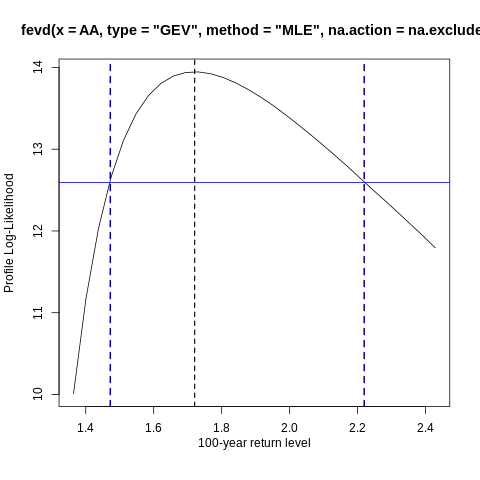

In [ ]:
# @title

# Import the extRemes package in R
# Transfer the 'annual_extremes' DataFrame to R

%%R -i annual_extremes -i levelType -o gev_params -o gev_params_se -o exceed_levs
library(extRemes)

AA <- annual_extremes$detrended_value

# Perform Generalized Extreme Value (GEV) analysis on the 'detrended_value' column
# using the fevd function from the extRemes package.
# We assume a GEV distribution and use maximum likelihood estimation ("MLE").
gev_fit <- fevd(AA, type = "GEV", method = "MLE", na.action=na.exclude)

# Print the summary of the GEV fit
summfit <- summary(gev_fit)

# You can extract parameters from the fitted model in R and transfer them back to Python if needed
# For example, to get the location, scale, and shape parameters:
# %%R -o gev_params # Removed as output transfer is handled by the %%R line
gev_params <- summfit$par
gev_params_se <- summfit$se.theta

exceed_levs <- data.frame(nrow=22,ncol=6)

# Calculate the 90% confidence intervals for the return period levels
# The "ci" function in extRemes calculates confidence intervals for given return periods.
# We specify the return periods (rp) and set alpha = 0.10 for the 90% confidence interval.
# The result is saved as citemp where the first value is the lower CI, the second value is the return level itself, and the third is the upper CI.
rp <- c(1.01,1.1,1.25,1.5,2,2.5,3.2,4,5,6.4,8,10,12.5,16,20,25,32,40,50,64,80,100)

# Select xrange expansion factors for increasing the range of levels in which to search for the maximum likelihood for the next higher return period requested
expand_high <- 1.6
expand_low <- 1.6

# Iterate through the 22 requested return periods from the lowest to the highest
k=1
for (m in rp)

# First calculate the normal confidence intervals for any return period
  { citemp <- ci(gev_fit, type='return.level', return.period = m, method="normal", alpha=0.1)
     middle = citemp[2]
     if ( m < 2) lower = middle - citemp[1]
     if ( m < 2) upper = citemp[3] - middle

# If the shape parameter is not below -0.3 we will try the profile likelihood method of calculating the confidence intervals
# in order to get non-symetric confidence intervals for return periods greater than or equal to 2 years
     if ( m >= 2 & gev_params[3] >= -0.3)
# Give the verbose output only for the return periods greater than or equal to 20 years
       if(m >= 20)
         {citemp <- ci(gev_fit, verbose = TRUE, type = "return.level", xrange = c(middle - lower * expand_low, middle + upper * expand_high), return.period = m, method = "proflik", alpha = 0.1, nint = 30)}
       else
         {citemp <- ci(gev_fit, verbose = FALSE, type = "return.level", xrange = c(middle - lower * expand_low, middle + upper * expand_high), return.period = m, method = "proflik", alpha = 0.1, nint = 30)}

#     print (c("lower", "upper", "lower ratio", "upper ratio"))
#     print(as.vector(c(lower, upper, (middle-citemp[1]) / lower, (citemp[3]-middle) / upper)))

     print(paste("exceedance level for ", m,"year return period"))
     print(paste("lower", "middle", "upper"))
     print(as.vector(round(citemp,3)))

# Save the confidence intervals for the current return period for use as the xrange bounds for the following higher return period when multiplied by the expansion factors exp_high and exp_low
     lower = citemp[2] - citemp[1]
     upper = citemp[3] - citemp[2]

     exceed_levs[k,1] <- "-999999"
     exceed_levs[k,2] <- 1 / m
     exceed_levs[k,3] <- m
     exceed_levs[k,4] <- citemp[2]
     exceed_levs[k,5] <- citemp[1]
     exceed_levs[k,6] <- citemp[3]

     if (levelType == 'low') exceed_levs[k,4] <- -exceed_levs[k,4]
     if (levelType == 'low') exceed_levs[k,5] <- -exceed_levs[k,5]
     if (levelType == 'low') exceed_levs[k,6] <- -exceed_levs[k,6]


     k <- k+1
   }

Note: You may want to increase or decrease the 'expand_high' or 'expand_low' parameters in the above code cell based on whether the plot above shows 2 crossings of the profile curve with the blue critical value line for a 90% confidence interval. Currently, 'expand_high' or 'expand_low' multiplier are 1.6 and 1.6.

In [ ]:
# @title Format the results.

# invert exceed_location if levelType is "low"

# warning: each time this cell is run the exceed_location parameter is inverted if levelType == 'low'

# exceed_location should probably be negative if levelType == 'low'
gev_type = 'GEV_HI'
if levelType == 'low':
  gev_params[0] = -gev_params[0]
  gev_type = 'GEV_LO'

last_data_year = annual_extremes.iloc[annual_extremes.shape[0]-1,1]

exceed_params = pd.Series({'station_id':station,'exceed_type':gev_type,'exceed_location':gev_params[0],'exceed_location_sd':gev_params_se[0],'exceed_scale':gev_params[1],
              'exceed_scale_sd':gev_params_se[1],'exceed_shape':gev_params[2],'exceed_shape_sd':gev_params_se[2],'last_data_year':last_data_year})

pd.DataFrame(exceed_params).transpose()

,station_id,exceed_type,exceed_location,exceed_location_sd,exceed_scale,exceed_scale_sd,exceed_shape,exceed_shape_sd,last_data_year
0,8638610,GEV_HI,0.690614,0.019042,0.166523,0.014467,0.122934,0.077368,2024


In [ ]:
# @title Format the exceedance level results
exceed_levs = exceed_levs.drop(columns='nrow')

exceed_levs.columns = ["exceed_prob","return_period","ext_lvl","ext_lvl_minus","ext_lvl_plus"]

exceed_levs = exceed_levs.round(3)

exceed_levs

,exceed_prob,return_period,ext_lvl,ext_lvl_minus,ext_lvl_plus
1,0.990,1.01,0.458,0.423,0.494
2,0.909,1.10,0.553,0.526,0.579
3,0.800,1.25,0.614,0.587,0.641
4,0.667,1.50,0.675,0.645,0.705
5,0.500,2.00,0.753,0.718,0.791
6,0.400,2.50,0.807,0.769,0.851
7,0.312,3.20,0.864,0.820,0.915
8,0.250,4.00,0.915,0.866,0.973
9,0.200,5.00,0.965,0.910,1.033
10,0.156,6.40,1.020,0.958,1.102


## **Step 7**
## Calculate the Weibull plotting positions for the annual extremes

### Subtask:
Create plots showing the relationship between exceedance levels and annual extreme levels in their Weibull plotting positions.  There are some alternatives to the Weibull plotting formula.

In [ ]:
# @title

# Calculation of the Weibull plotting positions
n = len(annual_extremes)
# Sort the annual extremes
sorted_extremes = annual_extremes['detrended_value'].sort_values(ascending=False).reset_index(drop=True)

# invert sorted_extremes if levelType is "low"
if levelType == 'low':
  sorted_extremes = [-level for level in sorted_extremes]

# Calculate the Weibull plotting position for the sorted annual extremes
# Formula: P_i = i / (n + 1), where i is the rank (starting from 1) and n is the total number of data points
ranks = np.arange(1, n + 1)
weibull_plotting_position = ranks / (n + 1)

# Create a DataFrame to store the sorted annual extremes and their Weibull plotting positions
weibull_df = pd.DataFrame({
    'Sorted_Annual_Extreme': sorted_extremes,
    'Weibull_Plotting_Position': weibull_plotting_position
})

# Display the DataFrame
print("\nSorted Annual Extremes with Weibull Plotting Position:")
display(weibull_df.head())
display(weibull_df.tail())


Sorted Annual Extremes with Weibull Plotting Position:


,Sorted_Annual_Extreme,Weibull_Plotting_Position
0,1.888378,0.010204
1,1.509875,0.020408
2,1.506335,0.030612
3,1.476475,0.040816
4,1.431082,0.051020


,Sorted_Annual_Extreme,Weibull_Plotting_Position
92,0.512768,0.948980
93,0.484182,0.959184
94,0.483418,0.969388
95,0.480542,0.979592
96,0.433502,0.989796


## **Step 8**
## Visualize exceedance levels with the annual extremes

### Subtask:
Create plots showing the relationship between exceedance levels and annual extreme levels in their Weibull plotting positions.

In [ ]:

# Create a figure object
fig = go.Figure()

# Define the tick positions and labels
aep_values = [1,.9,.8,.7,.6,.5,.4,.3,.2,.1,.09,.08,.07,.06,.05,.04,.03,.02,.01,.009,.008]
return_periods = ['100','90','80','70','60','50','40','30','20','10','9','8','7','6','5','4','3','2','1','0.9','0.8']

# --- 2. Traces now use f-strings for dynamic units ---

# a) Add the 'Extreme Level' trace.
fig.add_trace(go.Scatter(
    x=exceed_levs['exceed_prob'], y=exceed_levs['ext_lvl'],
    mode='lines',
    line=dict(color='black'),
    name='Extreme Level',
    hovertemplate=f'%{{y:.2f}} {unit_abbr}'  # <-- Dynamic unit
))

# b) Add the gray shading for the confidence interval (CI).
fig.add_trace(go.Scatter(
    x=exceed_levs['exceed_prob'], y=exceed_levs['ext_lvl_plus'],
    mode='lines',
    line=dict(width=0),
    showlegend=False,
    hoverinfo='skip'
))
fig.add_trace(go.Scatter(
    x=exceed_levs['exceed_prob'], y=exceed_levs['ext_lvl_minus'],
    mode='lines',
    line=dict(width=0),
    fillcolor='rgba(211, 211, 211, 0.5)',
    fill='tonexty',
    name='90% CI',
    customdata=exceed_levs['ext_lvl_plus'],
    hovertemplate=f'<b>90% CI</b><br>Upper: %{{customdata:.2f}} {unit_abbr}<br>Lower: %{{y:.2f}} {unit_abbr}<extra></extra>' # <-- Dynamic unit
))

# c) Add the 'annuals' data points.
fig.add_trace(go.Scatter(
    x=weibull_df['Weibull_Plotting_Position'], y=weibull_df['Sorted_Annual_Extreme'],
    mode='markers',
    marker=dict(color='cornflowerblue'),
    name='Annuals',
    hovertemplate=f'<b>Annuals</b><br>Level: %{{y:.2f}} {unit_abbr}<extra></extra>' # <-- Dynamic unit
))

# --- 3. Layout now uses the f-string for the y-axis title ---
fig.update_layout(
    title=f'Annual Exceedance Probability Levels for {station} {stationName}',
    xaxis_title='Annual Probability of Exceedance (AEP)',
    yaxis_title=f'Exceedance Level ({unit_abbr} relative to {datum})', # <-- Dynamic unit
    hovermode='x unified',
    title_x=0.5,
    showlegend=True,
    template='plotly_white',
    xaxis=dict(
        autorange="reversed",
        type="log",
        tickvals=aep_values,
        ticktext=return_periods
    )
)

fig.show()

In [ ]:
# @title Calculate 90% confidence intervals (ext_lvl_plus) using an alternative constant ratio method for exceedance levels for the 10% to 1% annual probability of exceedance.
# The alternative values can be inserted if the results from the profile-likelihood confidence curve begins to become jagged.
# Try changing the ratio of 1.2 set below to get a good fit of the part of the profile-likelihood curve before it becomes jagged.

# create a dataframe from exceed_levs with the exceed_prob, ext_lvl and ext_lvl_plus columns from rows 12 to 22
altern = exceed_levs.iloc[11:22, [0, 2, 4]].reset_index(drop=True)
altern.columns = ['exceed_prob','ext_lvl', 'ext_lvl_plus'] # Rename columns after iloc selection

# Initialize the new column 'ext_lvl_plus_alt'
altern['ext_lvl_plus_alt'] = 0.0

# Calculate an alternative constant ratio 90% confidence interval exceedance level for the 0.1 to 0.01 annual probability of exceedance
ratio = 1.18

# Apply the ratio to the exceedance levels for AEP from 0.1 down to 0.01
altern['ext_lvl_plus_alt'][0] = altern['ext_lvl_plus'][0]
for j in range(1, 11):
  altern['ext_lvl_plus_alt'][j] = altern['ext_lvl'][j] + (altern['ext_lvl_plus_alt'][j-1] - altern['ext_lvl'][j-1]) * ratio

#round to 3 digits
altern = altern.round(3)

# Display the new dataframe
display(altern)

,exceed_prob,ext_lvl,ext_lvl_plus,ext_lvl_plus_alt
0,0.100,1.122,1.236,1.236
1,0.080,1.174,1.309,1.309
2,0.062,1.233,1.395,1.392
3,0.050,1.288,1.475,1.475
4,0.040,1.343,1.562,1.564
5,0.031,1.406,1.662,1.667
6,0.025,1.465,1.760,1.773
7,0.020,1.524,1.860,1.887
8,0.016,1.592,1.983,2.021
9,0.012,1.656,2.098,2.162


In [ ]:
# @title Plot of the profile likelihood confidence and the alternative constant ratio method

# Create a figure object
fig = go.Figure()

# Define the tick positions and labels
aep_values = [1,.9,.8,.7,.6,.5,.4,.3,.2,.1,.09,.08,.07,.06,.05,.04,.03,.02,.01,.009,.008]
return_periods = ['100','90','80','70','60','50','40','30','20','10','9','8','7','6','5','4','3','2','1','0.9','0.8']

fig.add_trace(go.Scatter(
    x=exceed_levs['exceed_prob'], y=exceed_levs['ext_lvl'],
    mode='lines',
    line=dict(color='black'),
    name='Extreme Level',
    hovertemplate='%{y:.2f} m'
))

# Add the gray shading for the CI.
fig.add_trace(go.Scatter(
    x=exceed_levs['exceed_prob'], y=exceed_levs['ext_lvl_plus'],
    mode='lines', line=dict(width=0),
    showlegend=False,
    hoverinfo='skip'
))
fig.add_trace(go.Scatter(
    x=exceed_levs['exceed_prob'], y=exceed_levs['ext_lvl_minus'],
    mode='lines', line=dict(width=0),
    fillcolor='rgba(211, 211, 211, 0.5)', fill='tonexty',
    name='90% CI (Proflik)',
    customdata=exceed_levs['ext_lvl_plus'],
    hovertemplate='<b>90% CI (Proflik)</b><br>Upper: %{customdata:.2f} m<br>Lower: %{y:.2f} m<extra></extra>'
))

# Add the 'annuals' data points, removing the redundant probability.
fig.add_trace(go.Scatter(
    x=weibull_df['Weibull_Plotting_Position'], y=weibull_df['Sorted_Annual_Extreme'],
    mode='markers', marker=dict(color='lightblue'),
    name='Annuals',
    hovertemplate='<b>Annual Data</b><br>Level: %{y:.2f} m<extra></extra>'
))

# Add the Constant-Ratio CI, removing the redundant AEP.
fig.add_trace(go.Scatter(
    x=altern['exceed_prob'], y=altern['ext_lvl_plus_alt'],
    mode='lines', line=dict(color='purple'),
    name='90% CI (Constant-Ratio)',
    hovertemplate='<b>90% CI (Constant-Ratio)</b><br>Level: %{y:.2f} m<extra></extra>'
))

# Update layout
fig.update_layout(
    title=f'Annual Exceedance Probability for {station} {stationName}',
    xaxis_title='Annual Probability of Exceedance (AEP)',
    yaxis_title=f'Exceedance Level (meters relative to {datum})',
    hovermode='x unified', title_x=0.5, showlegend=True,
    template='plotly_white',
        xaxis=dict(
        autorange="reversed",
        type="log",
        tickvals=aep_values,
        ticktext=return_periods
    )
)
fig.update_layout(xaxis=dict(autorange="reversed", type="log"))

fig.show()

## **Takeaways**

###Thank you for taking the time to walk through this CO-OPS Extreme Value Analysis Notebook

###Some key takeaways include:

*   How to access CO-OPS data from the CO-OPS API (here is a [URL builder](https://tidesandcurrents.noaa.gov/api-helper/url-generator.html) if you want to explore other CO-OPS data)
*   How to calculate Annual Probability of Exceedance (AEP) from monthly high and low water level data
*   How to calculate the Weibull plotting positions for the annual extremes